<div dir="rtl" style="text-align: right; line-height: 1.9; font-family: 'Segoe UI', Tahoma, Arial, sans-serif; font-size: 16px;">

**[🡨 بازگشت به فصل نهم (معادلات دیفرانسیل جزئی FDM)](Fasl_9_Masterclass.ipynb)**

# 🎓 مسترکلاس مهندسی مالی تصادفی با پایتون
## فصل ۱۰: بهینه‌سازی سبد سرمایه‌گذاری (Portfolio Optimization & Markowitz)

---
### 🎯 هدف این نوت‌بوک (ایستگاه پایانی)
در فصول گذشته یاد گرفتیم چگونه ریسک و بازده یک دارایی منفرد را مدل‌سازی و پیش‌بینی کنیم. اما سرمایه‌گذاران عاقل هرگز تمام تخم‌مرغ‌های خود را در یک سبد نمی‌گذارند! **تئوری مدرن پورتفولیو (MPT)** که توسط هری مارکویتز ارائه شد، اثبات می‌کند که با ترکیب دارایی‌هایی که همبستگی (Correlation) کاملی با هم ندارند، می‌توان **ریسک کل سبد را کاهش داد** بدون آنکه بازده انتظاری کاهش یابد (جادوی تنوع‌بخشی یا Diversification).

در این مسترکلاس می‌آموزیم:
1. **ماتریس کوواریانس (Covariance Matrix):** محاسبه ریسک سیستماتیک و روابط بین دارایی‌ها در سبد.
2. **بهینه‌سازی میانگین-واریانس (Mean-Variance Optimization):** استفاده از برنامه‌ریزی ریاضی (Quadratic Programming) برای یافتن وزن‌های ایده‌آل هر سهم.
3. **شبیه‌سازی پورتفولیو:** تولید هزاران سبد تصادفی برای مصورسازی توزیع ریسک-بازده.
4. **رسم مرز کارا (The Efficient Frontier):** استخراج لبه بهینه‌ای که هیچ سبدی بهتر از آن در بازار وجود ندارد.

</div>

In [ ]:
# Install necessary packages for Chapter 10
!pip install scipy numpy pandas matplotlib seaborn yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
from typing import List, Dict

plt.style.use("seaborn-v0_8-darkgrid")
print("\n--- Setup Complete! Libraries for Portfolio Optimization are loaded. ---")


--- Setup Complete! Libraries for Portfolio Optimization are loaded. ---


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۱: ریاضیات تئوری پورتفولیو (MPT Mathematics)

فرض کنید یک سبد شامل $N$ دارایی داریم. وزن سرمایه‌گذاری شده در دارایی $i$ را با $w_i$ نشان می‌دهیم. بردار وزن‌ها $\mathbf{w} = [w_1, w_2, ..., w_N]^T$ است.
بازده انتظاری (میانگین) هر دارایی را با بردار $\boldsymbol{\mu}$ و ماتریس کوواریانس بازده‌ها را با $\Sigma$ نشان می‌دهیم.

۱. **بازده انتظاری پورتفولیو ($E[R_p]$):** میانگین وزنی بازده تک‌تک دارایی‌ها.
$$ E[R_p] = \mathbf{w}^T \boldsymbol{\mu} = \sum_{i=1}^N w_i \mu_i $$

۲. **واریانس پورتفولیو ($\sigma_p^2$):** نماینده ریسک کل. به دلیل وجود کوواریانس بین دارایی‌ها، این مقدار معمولاً کمتر از میانگین وزنی واریانس‌ها است.
$$ \sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w} $$

در کدهای زیر، یک کلاس شی‌گرا برای استخراج خودکار این پارامترها ($\boldsymbol{\mu}$ و $\Sigma$) از داده‌های واقعی بازار (سال ۲۰۲۰ تا ۲۰۲۳) طراحی می‌کنیم. دقت کنید که بازده‌ها را **سالانه (Annualized)** می‌کنیم تا اعداد برای سرمایه‌گذار ملموس باشند (ضرب در ۲۵۲ روز کاری).

</div>

In [ ]:
# --- 1. Portfolio Data Infrastructure (Zero-Dependency) ---

class PortfolioAssets:
    """
    Fetches historical prices, computes returns, and generates
    the Covariance Matrix (Σ) and Expected Returns vector (μ).
    """
    def __init__(self, tickers: List[str], start_date: str, end_date: str):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self._fetch_and_prepare_data()

    def _fetch_and_prepare_data(self):
        print(f"Fetching daily data for {self.tickers}...")
        # Download Adjusted Close prices
        data = yf.download(self.tickers, start=self.start_date, end=self.end_date, progress=False)['Close']

        # Compute Daily Log Returns (r_t = ln(S_t / S_{t-1}))
        self.daily_returns = np.log(data / data.shift(1)).dropna()

        # Annualize the returns and covariance matrix (252 trading days)
        self.mean_returns = self.daily_returns.mean() * 252
        self.cov_matrix = self.daily_returns.cov() * 252

    def get_portfolio_performance(self, weights: np.ndarray):
        """Calculates Expected Return and Volatility for a specific weight distribution."""
        p_return = np.sum(self.mean_returns * weights)
        p_variance = np.dot(weights.T, np.dot(self.cov_matrix, weights))
        p_volatility = np.sqrt(p_variance)
        return p_return, p_volatility

# Initialize Portfolio
assets = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
portfolio_data = PortfolioAssets(tickers=assets, start_date='2020-01-01', end_date='2023-12-31')

print("\n--- Annualized Mean Returns (μ) ---")
print(portfolio_data.mean_returns)
print("\n--- Annualized Covariance Matrix (Σ) ---")
display(portfolio_data.cov_matrix)

Fetching daily data for ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']...

--- Annualized Mean Returns (μ) ---
Ticker
AAPL     0.242648
AMZN     0.118015
GOOGL    0.178922
MSFT     0.222586
TSLA     0.541367
dtype: float64

--- Annualized Covariance Matrix (Σ) ---


/tmp/ipykernel_1008/1443728729.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(self.tickers, start=self.start_date, end=self.end_date, progress=False)['Close']


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Ticker,,,,,
AAPL,0.112583,0.079202,0.078245,0.085360,0.118828
AMZN,0.079202,0.141970,0.084356,0.083697,0.117297
GOOGL,0.078245,0.084356,0.112740,0.084794,0.099332
MSFT,0.085360,0.083697,0.084794,0.106476,0.106928
TSLA,0.118828,0.117297,0.099332,0.106928,0.463907


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۲: بهینه‌سازی پورتفولیوی مارکویتز (Markowitz Optimization)

مسئله مارکویتز یک مسئله **بهینه‌سازی درجه دوم (Quadratic Programming)** است. ما می‌خواهیم واریانس (ریسک) را برای یک سطح مشخص از بازده حداقل کنیم.

**تابع هدف (Objective Function):**
$$ \min_{\mathbf{w}} \frac{1}{2} \mathbf{w}^T \Sigma \mathbf{w} $$

**محدودیت‌ها (Constraints):**
1. مجموع وزن‌ها باید ۱۰۰٪ باشد: $\sum w_i = 1$ (کاملاً سرمایه‌گذاری شده).
2. بازده سبد باید برابر بازده هدف (Target Return) باشد: $\mathbf{w}^T \boldsymbol{\mu} = R_{target}$.
3. عدم اجازه فروش استقراضی (No Short-Selling): $0 \le w_i \le 1$ برای تمامی دارایی‌ها.

در کد زیر، کلاس `MarkowitzOptimizer` با استفاده از الگوریتم `SLSQP` در `scipy.optimize.minimize` این مسئله پیچیده ریاضی را حل کرده و وزن‌های بهینه را برمی‌گرداند.

</div>

In [ ]:
# --- 2. Markowitz Portfolio Optimizer (Quadratic Programming) ---

class MarkowitzOptimizer:
    """
    Finds the optimal asset weights to minimize variance for a given target return,
    subject to constraints w >= 0 and sum(w) = 1.
    """
    def __init__(self, portfolio_assets: PortfolioAssets):
        self.p_assets = portfolio_assets
        self.n_assets = len(self.p_assets.tickers)
        self.bounds = tuple((0.0, 1.0) for _ in range(self.n_assets)) # No short-selling constraint

    def _portfolio_variance(self, weights):
        # Objective Function: w^T * Σ * w
        return np.dot(weights.T, np.dot(self.p_assets.cov_matrix, weights))

    def optimize(self, target_return: float) -> dict:
        # Initial guess (equal weighting)
        init_guess = np.array(self.n_assets * [1. / self.n_assets])

        # Constraints
        constraints = (
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}, # sum of weights = 1
            {'type': 'eq', 'fun': lambda w: np.sum(w * self.p_assets.mean_returns) - target_return} # expected return = target
        )

        # Run the optimization
        result = minimize(
            fun=self._portfolio_variance,
            x0=init_guess,
            method='SLSQP',
            bounds=self.bounds,
            constraints=constraints,
            options={'disp': False, 'maxiter': 1000}
        )

        if result.success:
            opt_weights = result.x
            opt_ret, opt_vol = self.p_assets.get_portfolio_performance(opt_weights)
            return {
                'weights': np.round(opt_weights, 4),
                'return': opt_ret,
                'volatility': opt_vol
            }
        else:
            return None # No feasible solution for this target return

print("Optimizer Engine is Ready.")

Optimizer Engine is Ready.


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۳: شبیه‌سازی تصادفی و تولید مرز کارا (The Efficient Frontier)

برای درک کامل فضای سرمایه‌گذاری، ما دو کار انجام می‌دهیم:
1. **شبیه‌سازی مونت‌کارلو (Monte Carlo):** هزاران سبد با وزن‌های کاملاً تصادفی ایجاد می‌کنیم. این سبدها یک "ابر نقطه‌ای" (Scatter Cloud) تشکیل می‌دهند که به آن **مجموعه امکان‌پذیر (Feasible Set)** می‌گویند. هیچ سبدی نمی‌تواند خارج از این ناحیه (سمت چپ آن) وجود داشته باشد.
2. **رسم مرز کارا (Efficient Frontier):** با استفاده از `MarkowitzOptimizer`، بازه بازده‌های ممکن را از مینیمم تا ماکزیمم پیمایش می‌کنیم. برای هر بازده، کمترین ریسک ممکن را محاسبه کرده و خط لبه بالایی ابر نقطه‌ای را رسم می‌کنیم.

همچنین **پورتفولیوی حداقل واریانس جهانی (Global Minimum Variance Portfolio - GMV)** را مشخص می‌کنیم؛ نقطه‌ای که کمترین ریسک مطلق را در کل بازار دارد.

</div>

<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:79: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1008/268633794.py:78: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Risk (Annualized Volatility - $\sigma$)", fontsize=12)
/tmp/ipykernel_1008/268633794.py:79: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Expected Return (Annualized - $\mu$)", fontsize=12)


Simulating 10000 random portfolios...
Calculating the Mathematical Efficient Frontier...


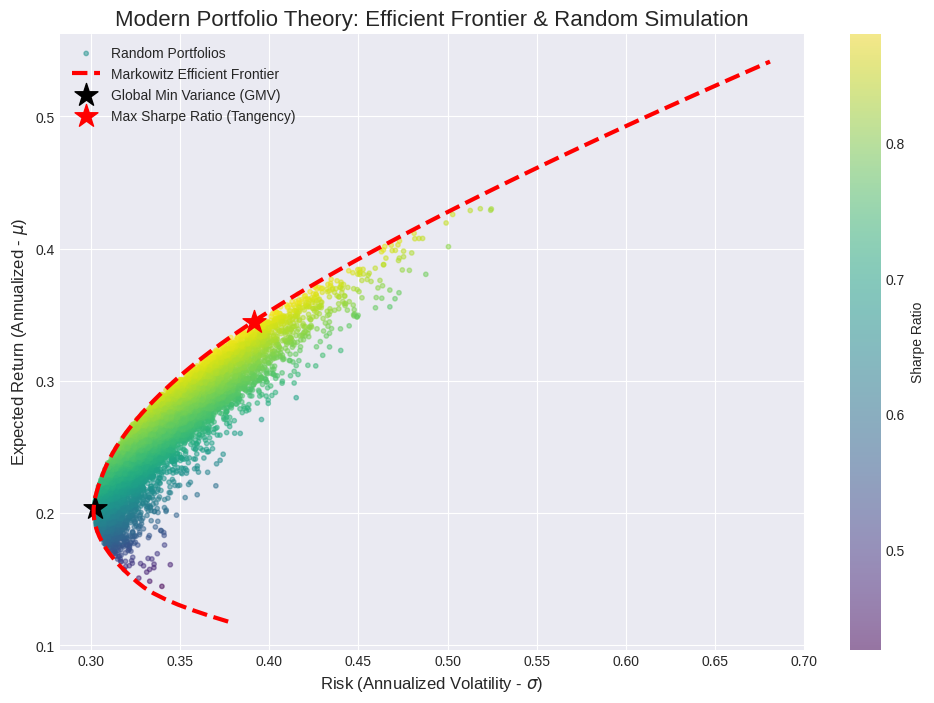

In [ ]:
# --- 3. Portfolio Simulation and Efficient Frontier Visualization ---

class PortfolioSimulator:
    def __init__(self, portfolio_assets: PortfolioAssets, n_simulations: int = 5000):
        self.p_assets = portfolio_assets
        self.n_simulations = n_simulations
        self.optimizer = MarkowitzOptimizer(self.p_assets)

    def simulate_random_portfolios(self):
        print(f"Simulating {self.n_simulations} random portfolios...")
        results = np.zeros((3, self.n_simulations))
        weights_record = []

        for i in range(self.n_simulations):
            # Generate random normalized weights (Dirichlet-like distribution)
            w = np.random.random(len(self.p_assets.tickers))
            w /= np.sum(w)

            p_ret, p_vol = self.p_assets.get_portfolio_performance(w)

            # Sharpe Ratio (assuming Risk-Free Rate = 0 for simplicity)
            sharpe_ratio = p_ret / p_vol

            results[0,i] = p_vol
            results[1,i] = p_ret
            results[2,i] = sharpe_ratio
            weights_record.append(w)

        return results, weights_record

    def calculate_efficient_frontier(self):
        print("Calculating the Mathematical Efficient Frontier...")
        min_ret = np.min(self.p_assets.mean_returns)
        max_ret = np.max(self.p_assets.mean_returns)

        target_returns = np.linspace(min_ret, max_ret, 100)
        frontier_volatility = []
        frontier_returns = []

        for ret in target_returns:
            opt_res = self.optimizer.optimize(target_return=ret)
            if opt_res is not None:
                frontier_volatility.append(opt_res['volatility'])
                frontier_returns.append(opt_res['return'])

        return frontier_volatility, frontier_returns

    def plot_masterclass_visualization(self):
        # Generate Data
        sim_results, _ = self.simulate_random_portfolios()
        front_vol, front_ret = self.calculate_efficient_frontier()

        # Find Global Minimum Variance Portfolio (GMV)
        min_vol_idx = np.argmin(sim_results[0,:])
        gmv_vol = sim_results[0, min_vol_idx]
        gmv_ret = sim_results[1, min_vol_idx]

        # Find Maximum Sharpe Ratio Portfolio (Tangency Portfolio)
        max_sharpe_idx = np.argmax(sim_results[2,:])
        msr_vol = sim_results[0, max_sharpe_idx]
        msr_ret = sim_results[1, max_sharpe_idx]

        # Plotting
        plt.figure(figsize=(12, 8))
        # Random Portfolios
        scatter = plt.scatter(sim_results[0,:], sim_results[1,:], c=sim_results[2,:],
                              cmap='viridis', marker='o', s=10, alpha=0.5, label='Random Portfolios')
        plt.colorbar(scatter, label='Sharpe Ratio')

        # Efficient Frontier
        plt.plot(front_vol, front_ret, 'r--', linewidth=3, label='Markowitz Efficient Frontier')

        # Optimal Points
        plt.scatter(gmv_vol, gmv_ret, marker='*', color='black', s=300, label='Global Min Variance (GMV)')
        plt.scatter(msr_vol, msr_ret, marker='*', color='red', s=300, label='Max Sharpe Ratio (Tangency)')

        plt.title("Modern Portfolio Theory: Efficient Frontier & Random Simulation", fontsize=16)
        plt.xlabel("Risk (Annualized Volatility - $\sigma$)", fontsize=12)
        plt.ylabel("Expected Return (Annualized - $\mu$)", fontsize=12)
        plt.legend(loc='upper left')
        plt.show()

# Execute the grand finale!
simulator = PortfolioSimulator(portfolio_assets=portfolio_data, n_simulations=10000)
simulator.plot_masterclass_visualization()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

---
### 🏁 نتیجه‌گیری فصل ۱۰ و پایان دوره
در این فصل، اوج هنر مهندسی مالی را مشاهده کردید:
1. ما ثابت کردیم که ترکیب تصادفی دارایی‌ها (نقاط پراکنده رنگی) یک مرز ریاضی مستحکم در سمت چپ ایجاد می‌کند که عبور از آن غیرممکن است.
2. خط چین قرمز رنگ (**مرز کارا**)، لبه طلایی سرمایه‌گذاری است. هر نقطه روی این خط، یک خروجی از الگوریتم بهینه‌ساز ماست که کمترین ریسک ممکن را برای یک بازده مشخص پیدا کرده است.
3. سبد **ستاره مشکی (GMV)** امن‌ترین سبد ممکن در کل بازار است.
4. سبد **ستاره قرمز (Max Sharpe)** سبدی است که بهترین نسبت پاداش به ریسک را ارائه می‌دهد.

**سخن پایانی دوره:**
از فصل ۱ (جذب داده خام) تا فصل ۱۰ (بهینه‌سازی مارکویتز)، شما معماری کامل یک سیستم مدرن **Quantitative Finance** را با پایتون فرا گرفتید. شما اکنون ابزارهایی برای شبیه‌سازی مونت‌کارلو، حل معادلات دیفرانسیل جزئی (PDE)، مدل‌سازی شوک‌های بازار (Jump Models)، قیمت‌گذاری آپشن‌ها (Black-Scholes) و بهینه‌سازی ریسک در اختیار دارید. این کُدها و مفاهیم، پایه و اساس الگوریتم‌هایی هستند که صندوق‌های پوشش ریسک (Hedge Funds) تراز اول جهان روزانه از آن‌ها استفاده می‌کنند.

**موفق و پیروز باشید!**

</div>